<a href="https://colab.research.google.com/github/paramak23/Drug-Likeness_Analysis/blob/main/Drug_likeness_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import google.colab
google.colab.drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 65.2 MB/s eta 0:00:00


In [3]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.DataStructs import FingerprintSimilarity
from rdkit.Chem import rdRGroupDecomposition as rdRGD
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import display
import os
import pandas as pd

In [4]:
root_directory = "/content/drive/MyDrive/Tool_Development_Projects/RDKit_Project/Medium_cheminformatics_article/Article_3"
csv_file = [csv_filename for csv_filename in os.listdir(root_directory) if csv_filename.endswith('.csv')]

for csv_filename in csv_file:
    csv_path = os.path.join(root_directory, csv_filename)
    df = pd.read_csv(csv_path)
    new_antibiotic_database = pd.DataFrame(df[['Compound_CID', 'IUPAC_Name', 'SMILES']])
    csv_newfilename = 'antibiotic_data.csv'
    csv_newfilepath = os.path.join(root_directory, csv_newfilename)
    new_antibiotic_database.to_csv(csv_newfilepath)

In [9]:
import os
import pandas as pd
import numpy as np # Added for efficient conditional labeling
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit import RDLogger
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns


def lipinski_checker(df):
    RDLogger.DisableLog('rdApp.warning')

    # 1. Create Mol objects once
    df['_mol'] = df['SMILES'].apply(lambda x: Chem.MolFromSmiles(x) if pd.notna(x) else None)
    valid_mask = df['_mol'].notna()

    # 2. Calculate Descriptors (using loc to avoid SettingWithCopy warnings)
    df.loc[valid_mask, 'Standard_SMILES'] = df.loc[valid_mask, '_mol'].apply(Chem.MolToSmiles)
    df.loc[valid_mask, 'MW'] = df.loc[valid_mask, '_mol'].apply(Descriptors.MolWt)
    df.loc[valid_mask, 'LogP'] = df.loc[valid_mask, '_mol'].apply(Descriptors.MolLogP)
    df.loc[valid_mask, 'HBD'] = df.loc[valid_mask, '_mol'].apply(Descriptors.NumHDonors)
    df.loc[valid_mask, 'HBA'] = df.loc[valid_mask, '_mol'].apply(Descriptors.NumHAcceptors)
    df.loc[valid_mask, 'TPSA'] = df.loc[valid_mask, '_mol'].apply(Descriptors.TPSA)
    df.loc[valid_mask, 'RotBonds'] = df.loc[valid_mask, '_mol'].apply(Descriptors.NumRotatableBonds)

    # 3. Define Lipinski Criteria (Pass = 1, Fail = 0)
    c1 = (df['MW'] <= 500).astype(int)
    c2 = (df['LogP'] <= 5).astype(int)
    c3 = (df['HBD'] <= 5).astype(int)
    c4 = (df['HBA'] <= 10).astype(int)

    # 4. Calculate Lipinski Passes (Standard Ro5 allows 1 violation)
    total_lipinski_pass = c1 + c2 + c3 + c4
    df['Lipinski_Violations'] = 4 - total_lipinski_pass
    df['Lipinski_Ro5_Passes'] = np.where(total_lipinski_pass >= 3, 'Yes', 'No')

    # 5. Define Veber Criteria
    veber_pass = (df['TPSA'] <= 140) & (df['RotBonds'] <= 10)

    # 6. DRUG-LIKENESS (Lipinski AND Veber)
    # This replaces the buggy 'if' statement
    drug_like_mask = (df['Lipinski_Ro5_Passes'] == 'Yes') & veber_pass
    df['Drug_Likeness'] = np.where(drug_like_mask, 'Yes', 'No')



    # Clean up
    df.drop(columns=['_mol'], inplace=True)
    RDLogger.EnableLog('rdApp.warning')
    return df

# File Handling
csv_root_dir = '/content/drive/MyDrive/Tool_Development_Projects/RDKit_Project/Medium_cheminformatics_article/Article_3'
csv_filename = 'antibiotic_data.csv'
csv_filepath = os.path.join(csv_root_dir, csv_filename)

# Check if file exists before reading to avoid FileNotFoundError
if os.path.exists(csv_filepath):
    df_data = pd.read_csv(csv_filepath, index_col=0)
    RDLogger.DisableLog('rdApp.warning')
    df_data['Standard_SMILES'] = df_data['SMILES'].apply(lambda x: Chem.MolToSmiles(Chem.MolFromSmiles(x)) if pd.notna(x) else None)
    cleaned_df = df_data.drop_duplicates(subset=['Standard_SMILES']).copy()
    drop_duplicates = len(df_data) - len(cleaned_df)
    print(f"Number of duplicate entries found and removed: {drop_duplicates}")
    RDLogger.EnableLog('rdApp.warning')
    processed_df = lipinski_checker(cleaned_df)

    print("Processing Complete!")
    display(cleaned_df.head())
else:
    print(f"Error: File not found at {csv_filepath}")

Number of duplicate entries found and removed: 0
Processing Complete!


,Compound_CID,IUPAC_Name,SMILES,Standard_SMILES,MW,LogP,HBD,HBA,TPSA,RotBonds,Lipinski_Violations,Lipinski_Ro5_Passes,Drug_Likeness
0,16131155,"(1S,2R,19R,22R,34S,37R,40R,52S)-22-amino-5,15,...",C1[C@@H]2C(=O)N[C@@H](C3=CC(=CC(=C3)OC4=C(C=CC...,N[C@H]1C(=O)N[C@@H]2Cc3ccc(c(Cl)c3)Oc3cc4cc(c3...,1313.444,5.1142,15.0,20.0,450.59,3.0,4,No,No
1,6439108,4-[(Z)-2-hydroxy-5-methyl-7-(3-methyloxiran-2-...,CC1C(O1)/C(=C\C(C)C(=O)CC(CC2CC(=O)NC(=O)C2)O)/C,C/C(=C/C(C)C(=O)CC(O)CC1CC(=O)NC(=O)C1)C1OC1C,323.389,1.1191,2.0,5.0,96.00,7.0,0,Yes,Yes
2,9690107,"(6R,7R)-7-[[(2Z)-2-(carboxymethoxyimino)-2-(1,...",C1C=C(N2[C@H](S1)[C@@H](C2=O)NC(=O)/C(=N\OCC(=...,O=C(O)CO/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)O)=CC...,412.405,-0.6832,3.0,9.0,158.49,7.0,0,Yes,No
3,125607,"7,10-bis[[4-(dimethylamino)-5-[5-(5-hydroxy-6-...",CCC1(CC(C2=C(C1OC3CC(C(C(O3)C)OC4CCC(C(O4)C)OC...,CCC1(O)CC(OC2CC(N(C)C)C(OC3CCC(OC4CCC(O)C(C)O4...,1157.358,5.7318,6.0,22.0,272.76,15.0,4,No,No
4,5487319,6-[(1R)-1-[(2R)-3-hydroxy-2-methoxypropanoyl]o...,C[C@H](C1=C2C(=CC=C1)N=C3C(=N2)C=CC=C3C(=O)O)O...,CO[C@H](CO)C(=O)O[C@H](C)c1cccc2nc3c(C(=O)O)cc...,370.361,2.0927,2.0,7.0,118.84,6.0,0,Yes,Yes


In [6]:
display(cleaned_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 2356 entries, 0 to 2355
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Compound_CID         2356 non-null   int64  
 1   IUPAC_Name           2346 non-null   object 
 2   SMILES               2356 non-null   object 
 3   Standard_SMILES      2356 non-null   object 
 4   MW                   2356 non-null   float64
 5   LogP                 2356 non-null   float64
 6   HBD                  2356 non-null   float64
 7   HBA                  2356 non-null   float64
 8   TPSA                 2356 non-null   float64
 9   RotBonds             2356 non-null   float64
 10  Lipinski_Violations  2356 non-null   int64  
 11  Lipinski_Ro5_Passes  2356 non-null   object 
 12  Drug_Likeness        2356 non-null   object 
dtypes: float64(6), int64(2), object(5)
memory usage: 257.7+ KB


None

Drug Likeness Distribution:
Drug_Likeness
No     1627
Yes     729
Name: count, dtype: int64


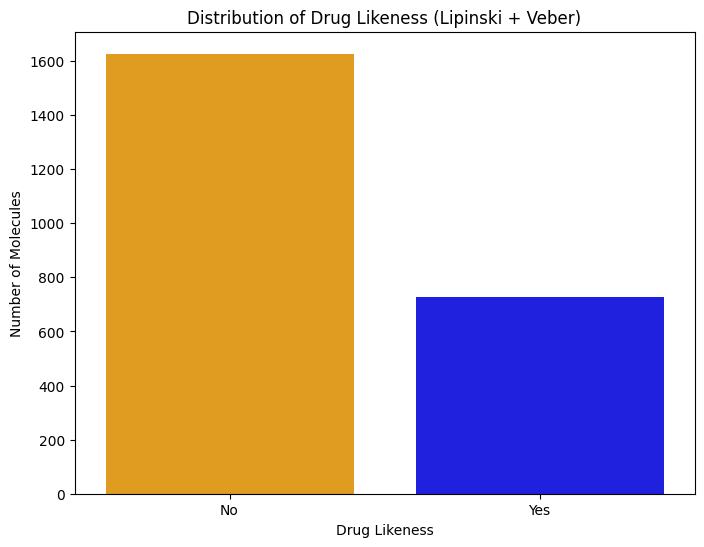

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
# Count the occurrences of 'Yes' and 'No' in the 'Drug_Likeness' column
drug_likeness_counts = cleaned_df['Drug_Likeness'].value_counts()

# Display the counts
print("Drug Likeness Distribution:")
print(drug_likeness_counts)

# Define a custom color palette for 'Yes' and 'No'
custom_palette = {
    'No': 'orange',
    'Yes': 'blue' # A dark purple from 'viridis'
}

# Ensure the palette is ordered correctly based on the index of drug_likeness_counts for visual consistency
ordered_palette = [custom_palette[cat] for cat in drug_likeness_counts.index]

# Create a bar plot with custom colors
plt.figure(figsize=(8, 6))
sns.barplot(x=drug_likeness_counts.index, y=drug_likeness_counts.values, palette=ordered_palette, hue=drug_likeness_counts.index, legend=False)
plt.title('Distribution of Drug Likeness (Lipinski + Veber)')
plt.xlabel('Drug Likeness')
plt.ylabel('Number of Molecules')
plt.show()

In [11]:
total_molecules = drug_likeness_counts.sum()
drug_like_percentage = (drug_likeness_counts['Yes'] / total_molecules) * 100

print(f"Total molecules analyzed: {total_molecules}")
print(f"Number of drug-like molecules: {drug_likeness_counts['Yes']}")
print(f"Percentage of drug-like molecules: {drug_like_percentage:.2f}%")

Total molecules analyzed: 2356
Number of drug-like molecules: 729
Percentage of drug-like molecules: 30.94%


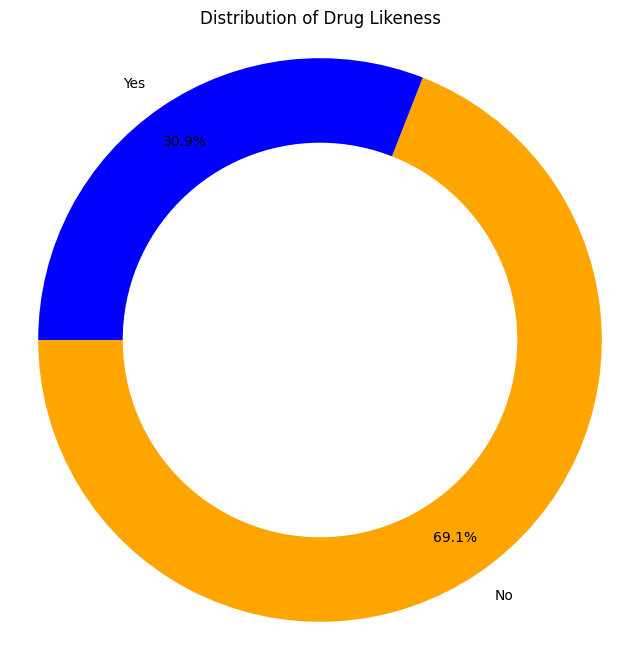

In [12]:

# Assuming drug_likeness_counts is already available from previous cells
# If not, uncomment and run the following lines:
# drug_likeness_counts = cleaned_df['Drug_Likeness'].value_counts()

labels = drug_likeness_counts.index
sizes = drug_likeness_counts.values

# Define a custom color palette: 'Yes' to green, 'No' to red
custom_palette_updated = {
    'No': 'orange',
    'Yes': 'blue'
}

colors = [custom_palette_updated[label] for label in labels] # Use the updated custom_palette

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=180, pctdistance=0.85)

# Draw a circle in the center to make it a donut chart
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Distribution of Drug Likeness')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()